In [4]:
import sys
import os
from pathlib import Path
import importlib

# 添加根目录到 path 以便导入 plot_functions
root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import read_training_csv, plot_learning_curves

## Plot Learning Curves

Use the new `plot_learning_curves` function to visualize learning curves with rolling average smoothing.


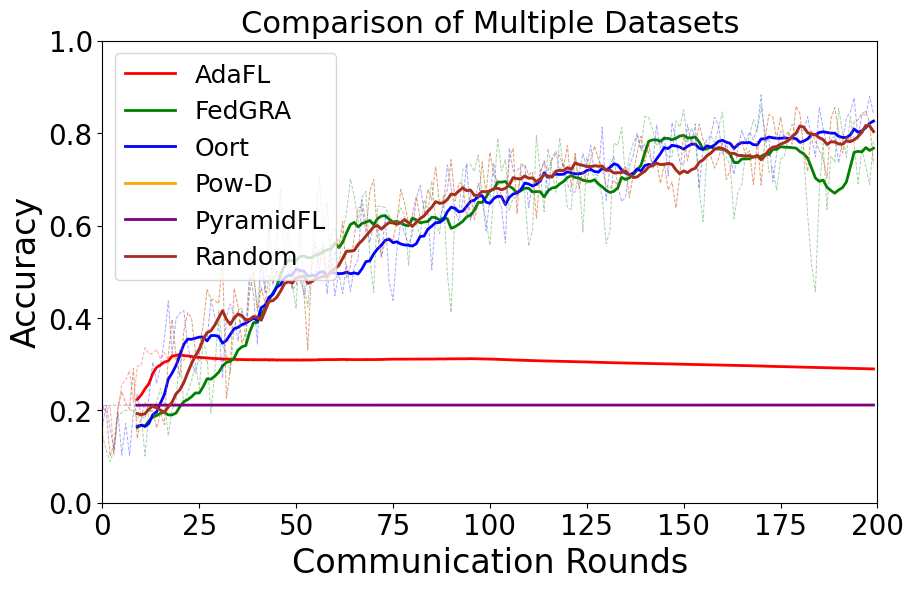

In [5]:
# Example 3: Compare multiple datasets
# Load additional files for comparison
files_compare = [
    "./mnist_series/train-20260210_020308-eb4fea9f.csv",
    "./mnist_series/train-20260210_020558-eb4fea9f.csv",
    "./mnist_series/train-20260210_021936-eb4fea9f.csv",
    "./mnist_series/train-20260210_022219-eb4fea9f.csv",
    "./mnist_series/train-20260210_022509-eb4fea9f.csv",
    "./mnist_series/train-20260210_022754-eb4fea9f.csv",
]

# Load all files more efficiently (use header=2 for these CSVs)
data_dict = {}
for i, file_path in enumerate(files_compare):
    df_temp = read_training_csv([file_path], columns=["accuracy"], header=1)
    data_dict[f"Dataset {i+1}"] = df_temp["accuracy"]

# Provide sufficient colors for all datasets
colors_list = ["red", "green", "blue", "orange", "purple", "brown"]

# legend_map must be a dict mapping the keys in data_dict to desired legend labels
legend_map = {
    "Dataset 1": "AdaFL",
    "Dataset 2": "FedGRA",
    "Dataset 3": "Oort",
    "Dataset 4": "Pow-D",
    "Dataset 5": "PyramidFL",
    "Dataset 6": "Random",
}

plot_learning_curves(
    data_dict,
    x_range=200,
    colors=colors_list,
    legend_map=legend_map,
    title="Comparison of Multiple Datasets",
    y_label="Accuracy",
    y_lim=[0, 1],
    figsize=(10, 6),
    window_size=10,
    is_legend=True
)
